# Airglow modeling (with new framework)

In [174]:
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from importlib import reload
from scipy import interpolate
import sys
import os
from scipy import signal
import obspy

import airglow_response as ar

## Airglow scaler
Take any moment tensor source $(M_w$, strike, dip, rake, depth$)$. 

Take a range of azimuth / distances to get some variability in waveforms. Normalize each velocity waveform by 1. Normalize each displacement waveform by the same factor as the velocity.

Calculate the intensity perturbation $100\Delta I/I_{\text{background}}$ (in %).

Plot the maximum in different frequency bands, centered (logaritmically) around 0.001 Hz, 0.01 Hz, 0.1 Hz and 1 Hz.

Total grid size:  441


100%|████████████████████████████████████████| 441/441 [00:00<00:00, 3645.21it/s]                                                               

Size of VEL, DIS (bytes):  21168000


Using Balthasar Kenda's attenuation data
(69, 34, 101)
Amplification minimum for Lon=30.0, Lat=5.0, at LTST=14.4h
Amplification maximum for Lon=-135.0, Lat=-15.0, at LTST=1.4h


NameError: name 'quit' is not defined

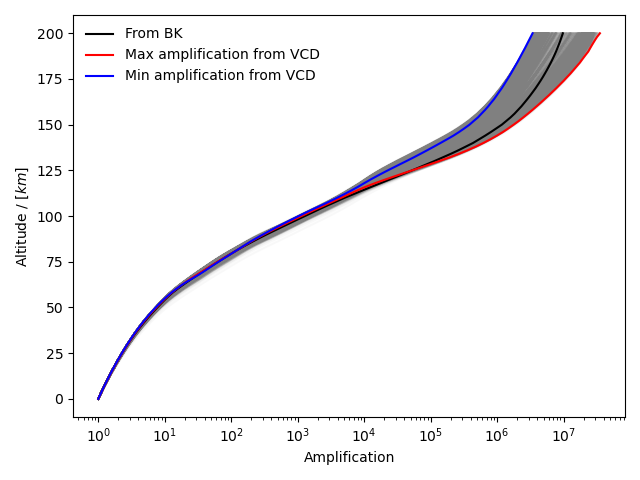

In [173]:
reload(ar)
ar.compute_airglow_scaler_new(mw = 1, strike=45, dip=45, rake=45, do_plot=True, tit="_Cold100",
                             store_ids_dists = [('GF_venus_Cold100_atten_qssp_nearfield',0e3,50e3),('GF_venus_Cold100_atten_qssp',50e3,8000e3)])
ar.compute_airglow_scaler_new(mw = 1, strike=45, dip=45, rake=45, do_plot=True, tit="_Hot10",
                             store_ids_dists = [('GF_venus_Hot10_atten_qssp_nearfield',0e3,50e3),('GF_venus_Hot10_atten_qssp',50e3,8000e3)])
ar.compute_airglow_scaler_new(mw = 1, strike=45, dip=45, rake=45, do_plot=True, tit="_Hot25",
                             store_ids_dists = [('GF_venus_Hot25_atten_qssp_nearfield',0e3,50e3),('GF_venus_Hot25_atten_qssp',50e3,8000e3)])
ar.compute_airglow_scaler_new(mw = 1, strike=45, dip=45, rake=45, do_plot=True, tit="_Hot40",
                             store_ids_dists = [('GF_venus_Hot40_atten_qssp_nearfield',0e3,50e3),('GF_venus_Hot40_atten_qssp',50e3,8000e3)])




### SOME TESTS of sensitivity to Mw, mechanism, amplification curves. 
# ar.compute_airglow_scaler_new(mw = 5, strike=45, dip=45, rake=45, do_plot=True)  ### Check that this measure is independant of mw.
# ar.compute_airglow_scaler_new(mw = 1, strike=45, dip=0, rake=45, do_plot=True)
# ar.compute_airglow_scaler_new(mw = 1, strike=90, dip=0, rake=0, do_plot=True)    ### Check that this measure is independant of MT. 
# ar.compute_airglow_scaler_new(mw = 1, strike=45, dip=45, rake=45, do_plot=True, effect="ampl")  ### Check effect of amplification curves 

## Determine airglow waveforms for specific examples
Converts seismic vertical velocities determined through QSSP into dayglow and nightglow Intensity perturbations

### Build QSSP traces

In [175]:
reload(ar)

### First, define the grid of locations. 
gridded       = False
min_grid_dist = 50e3
max_grid_dist = 8000e3 # 4000e3
delta_dist    = 50e3 
north_shifts  = np.arange( min_grid_dist, max_grid_dist, delta_dist)
east_shifts   = np.array([0. for i in range(north_shifts.size)])
    
### Source depths 
# delta_depth = 5e3
# depths = np.arange(5e3, 50e3+delta_depth, delta_depth)

### Option for Pyrocko 
opt_synthetics = dict(
    ### Options for source 
    mw = 7.5,              ### if none: We only get the Green's function
    depth = 10e3,          ### Only one depth
    strike = 0.,           ### Default mechanism 
    dip =  45., 
    rake = 45.,
    #stf_type = None,       ### Dirac source 
    #stf_type = 'triangle', 
    stf_type = 'sinus', 
    effective_duration = 25.,
    ###  
    ### Options for store
    base_folder='/projects/restricted/infrasound/data/infrasound/2023_Venus_inversion/',
    ### Old option, single store 
    #store_id = 'GF_venus_Cold100_qssp',
    #store_id = 'GF_venus_Cold100_qssp_grid',
    ### Give store names, and min and max valid distance 
    #store_ids_dists = [('GF_venus_Cold100_qssp_grid',0e3,500e3),('GF_venus_Cold100_qssp_grid_mid',500e3,8000e3)],
    store_ids_dists = [('GF_venus_Cold100_atten_qssp_nearfield',0e3,50e3),('GF_venus_Cold100_atten_qssp',50e3,8000e3)],
    ###
    ### Options for grid 
    north_shifts = north_shifts, 
    east_shifts = east_shifts,
    gridded=gridded
)

### INITIALIZE SEISMOGRAM CLASS 
### we build seismograms over grid
### 
SEISMO = ar.Seismograms(**opt_synthetics)
print("Total grid size: ", SEISMO.NN.size)

Total grid size:  159


### Plot traces 

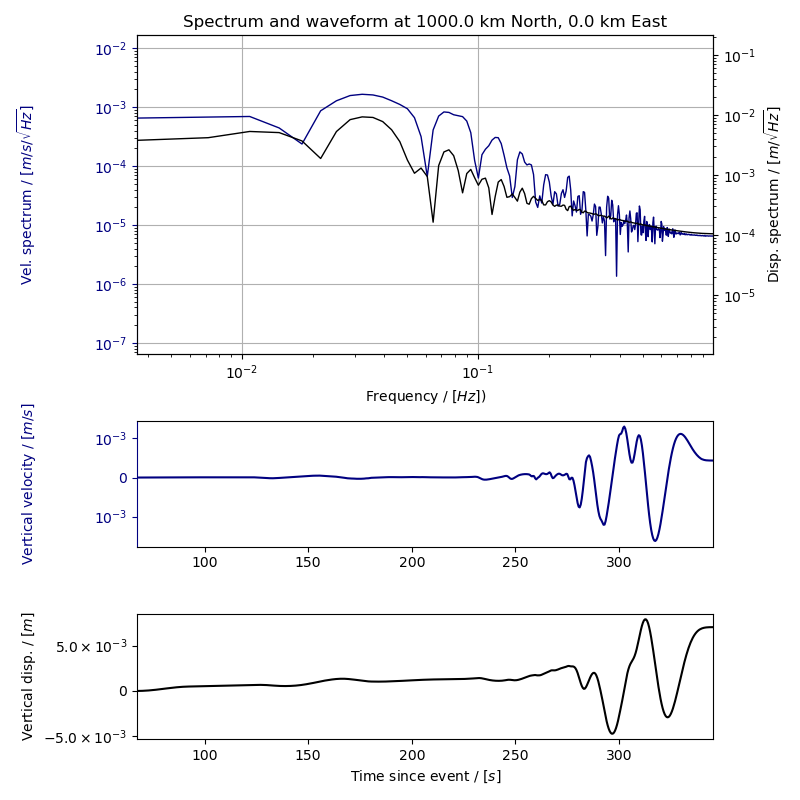

In [176]:
ns, es       = 1000e3, 0e3
### Plot one of the waveforms for check
fig = SEISMO.plot_traces(ns, es, do_interpolate=False)

### Arrange the synthetics
Sort QSSP synthetics by their location in the appropriate grid. Interpolate in time from $t=0$ to $t=tmax$.

In [182]:
reload(ar)
SEISMO.arrange_interpolate_synthetics(tmax=3000, dt=0.5)

100%|████████████████████████████████████████| 159/159 [00:00<00:00, 5053.45it/s]                                                               

Size of VEL, DIS (bytes):  7632000


()

### Initialize the AIRGLOW class
We load atmospheric parameters, background emission, etc. 

In [192]:
### Load airglow class 
reload(ar)
AIRGLOW = ar.AirglowSignal(SEISMO)

Using Balthasar Kenda's attenuation data


### Calculate the Airglow waveforms
Can be done in parallel or in serial. It is important to check what kind of information we want to save here, as full grids can be heavy. Here, we only have few locations, so we will calculate airglow for all of them. 

In [193]:
reload(ar)

dir_save="./results_detectability/"
if not os.path.exists(dir_save):
    os.makedirs(dir_save)
dir_save += "singletrace_"
list_inorth, list_ieast = AIRGLOW.iNN, [0 for i in range(AIRGLOW.Nn)]
# print(list_inorth, list_ieast)

### Calculation of the Nightglow 
AIRGLOW.calculate_1_27_airglow(list_ieast, list_inorth, loc_save_idx=[],
                                do_parallel=True, 
                                fourier_filtering=False,   ### Use time filtering 
                                dir_save = dir_save,
                                time_save = AIRGLOW.t_new) ### Save all timesteps 

### Calculation of the Dayglow
AIRGLOW.calculate_4_28_airglow(list_ieast, list_inorth, loc_save_idx=[],
                        do_parallel=True, 
                        dir_save=dir_save, 
                        time_save = AIRGLOW.t_new) ### Save all timesteps 

(East, North) location indices that will be saved:  []


100%|████████████████████████████████████████| 159/159 [00:04<00:00, 35.52it/s]                                                                 


Time for airglow calculation: 5.1 s
Re-aranging gridded wavefield...


100%|████████████████████████████████████████| 159/159 [00:00<00:00, 879.03it/s]                                                                

Saving gridded wavefield...


...

100%|████████████████████████████████████████| 159/159 [00:00<00:00, 196.04it/s]                                                                


Time for dayglow calculation: 1.4 s
Re-aranging gridded dayglow wavefield...


100%|████████████████████████████████████████| 159/159 [00:00<00:00, 955.24it/s]                                                                

Saving gridded dayglow wavefield...


Grid save completed.


### Plot the traces
We plot the nightglow and dayglow traces

0 59


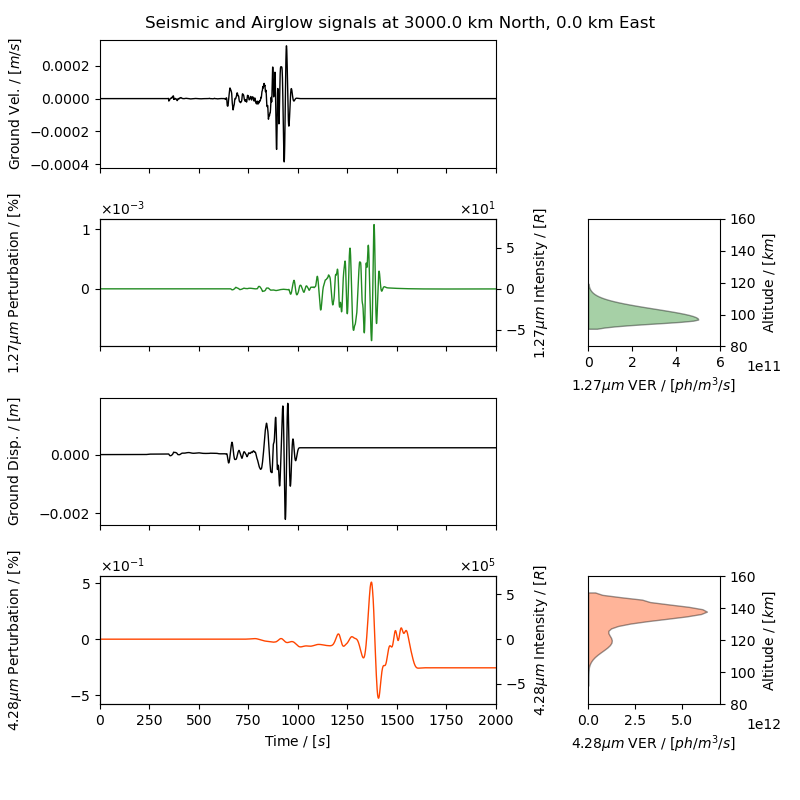

In [194]:
from matplotlib.gridspec import GridSpec
plt.close("all")
c_dayglow = "orangered"
c_nightglow = "forestgreen"
### Load VER grids:
I_nightglow = np.load(dir_save + "nightglow_I_t.npy")
VER_Vz_nightglow = np.load(dir_save + "nightglow_dver_t.npy")
I_dayglow = np.load(dir_save + "dayglow_I_t.npy")
VER_Uz_dayglow = np.load(dir_save + "dayglow_dver_t.npy")

time = AIRGLOW.t_new
###
z_ver_127 = AIRGLOW.z_1_27_calc_m  ### Always in meter
z_ver_428 = AIRGLOW.z_4_28_calc_m  ### Always in meter
### Background VER 
VER_127 = AIRGLOW.f_VER_1_27(z_ver_127) 
VER_428 = AIRGLOW.f_VER_4_28(z_ver_428)
### Background Intensity 
I_background_nightglow = AIRGLOW.I_background_nightglow
I_background_dayglow   = AIRGLOW.I_background_dayglow


### Select a location: 
ns, es       = 3000e3, 0e3
idx = np.argmin(np.sqrt((AIRGLOW.NN-ns)**2+(AIRGLOW.EE-es)**2)) 
i_east, i_north = 0, idx
print(i_east, i_north)

### Create figure
fig = plt.figure(figsize=(8, 8))
fig.suptitle("Seismic and Airglow signals at {:.1f} km North, {:.1f} km East".format(AIRGLOW.NN[i_north]/1e3,
                                                                                    AIRGLOW.EE[i_east]/1e3))
gs = GridSpec(4, 2, figure=fig, width_ratios=[3, 1])

axes = [fig.add_subplot(gs[i, 0]) for i in range(4)] 
axv1 = fig.add_subplot(gs[1, 1])
axv2 = fig.add_subplot(gs[3, 1])

axes[0].plot(time, AIRGLOW.VEL[i_east, i_north,:], c="k", lw=1)
axes[0].set_ylabel(r"Ground Vel. / [$m/s$]")
###
axes[1].plot(time, I_nightglow[i_east, i_north, :]/I_background_nightglow*100, ls=" ", lw=1)#ls="-", c="b")
axes[1].set_ylabel(r"1.27$\mu m$ Perturbation / [%]")
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
ax1b = axes[1].twinx()   ### Plot as purcentage of background intensity 
ax1b.plot(time, I_nightglow[i_east, i_north, :], c=c_nightglow, lw=1)
ax1b.set_ylabel(r"1.27$\mu m$ Intensity / [$R$]")
ax1b.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)

###
axes[2].plot(time, AIRGLOW.DIS[i_east, i_north,:], c="k", lw=1)
axes[2].set_ylabel(r"Ground Disp. / [$m$]")
###
axes[3].plot(time, I_dayglow[i_east, i_north, :]/I_background_dayglow*100, ls=" ", lw=1)#ls="-", c="b")
axes[3].set_ylabel(r"4.28$\mu m$ Perturbation / [%]")
axes[3].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
ax3b = axes[3].twinx()   ### Plot as purcentage of background intensity 
ax3b.plot(time, I_dayglow[i_east, i_north, :], c=c_dayglow, lw=1)
ax3b.set_ylabel(r"4.28$\mu m$ Intensity / [$R$]")
ax3b.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
        

### Plot VER profiles 
axv1.fill_betweenx(z_ver_127/1e3, 0, VER_127, edgecolor="k", facecolor=c_nightglow, alpha=0.4)
axv1.set_ylabel(r"Altitude / [$km$]")
axv1.set_xlabel(r"1.27$\mu m$ VER / [$ph/m^3/s$]")
###
axv2.fill_betweenx(z_ver_428/1e3, 0, VER_428, edgecolor="k", facecolor=c_dayglow, alpha=0.4)
axv2.set_ylabel(r"Altitude / [$km$]")
axv2.set_xlabel(r"4.28$\mu m$ VER / [$ph/m^3/s$]")


###
axes[-1].set_xlabel("Time / [$s$]")
for ax in axes:
    ax.set_xlim(0,2000)
axv1.set_xlim(0, 6e11)
axv2.set_xlim(0, 7e12)
for ax in [axv1, axv2]:
    ax.set_ylim(80,160)
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.xaxis.get_offset_text().set_position((1.2, 1.0))  # (x, y) in axis coordinates
    ax.xaxis.get_offset_text().set_horizontalalignment('left')
    ax.xaxis.get_offset_text().set_verticalalignment('bottom')
for ax in axes[:-1]:
    ax.set_xticklabels([])

fig.subplots_adjust(hspace=0.4, wspace=0.35, bottom=0.12, top=0.95)
fig.align_labels()
fig.savefig(dir_save + "Nightglow_Dayglow_traces_east_{:.0f}_north_{:.0f}km.png".format(
                                                        AIRGLOW.EE[i_east]/1e3, AIRGLOW.NN[i_north]/1e3), dpi=300)

### TEST: 
TO ENSURE THE TIME-SHIFT OF U IS DONE CORRECTLY

0.5
hermitian_error: 0.0
self_conj_error: 0.0


/nobackup/marouchka/miniconda/envs/mcmc/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/nobackup/marouchka/miniconda/envs/mcmc/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


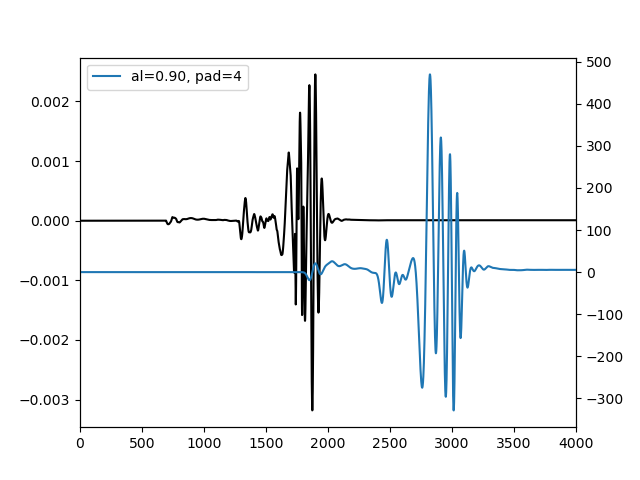

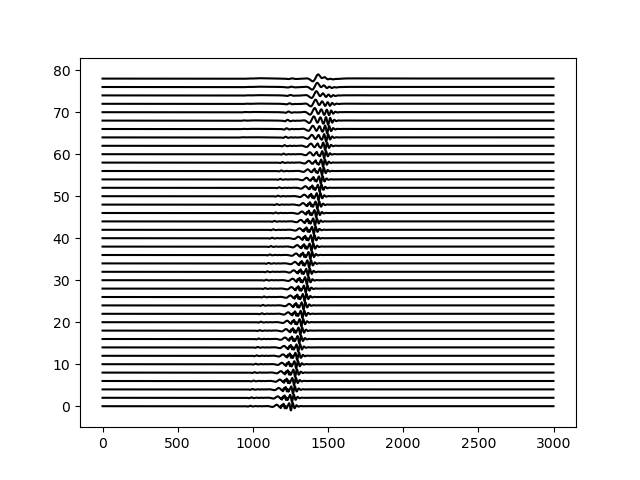

In [118]:
### HANDMADE TEST 
iz = 35

### We try to do the ropgation + attenuation step ourselves to avoid the step pb in FFT 
### 1. Pad signal in time domain with zeros 
orig_sig = AIRGLOW.DIS[i_east, i_north, :]
Nw = orig_sig.size
print(AIRGLOW.dt)
dpad = 4
### Better pad: tukey taper
from scipy.signal.windows import tukey
fig, ax = plt.subplots()
ax.plot(orig_sig, "k")
#ax.plot(long_sig, "r")    
axb = ax.twinx()
# for dpad in [4,8,12]:
# for al in [0.8, 0.9, 0.95]:
dpad = 4 
al = 0.9
long_sig = np.pad(orig_sig, ((0, int(dpad*Nw) )), mode='constant')
long_sig[Nw:] = tukey(int(2*dpad*Nw), alpha=al)[int(dpad*Nw):]*orig_sig[-1]
#ax.plot(tukey(int(8*Nw), alpha=0.5), "b")
### 2 Apply fft 
# print(orig_sig.shape)
long_sig_fft = np.fft.fft(long_sig)
Nfft = long_sig.size
## Nfft is 1875 in this example
### 3 calculate attenuation 
pad_freq = np.fft.fftfreq(Nfft, AIRGLOW.dt)
FFver, ZZver2 = np.meshgrid(abs(pad_freq), AIRGLOW.z_att_4_28_m)
attenuation = AIRGLOW.f_alpha_2d((ZZver2, FFver))
att_exp = np.exp(-AIRGLOW.dz_4_28_m*np.cumsum(attenuation, axis=0))   ### Supposes Np/m 
att_exp = att_exp[-AIRGLOW.Nz:,:]
### 4 Calculate phase shift 
phase_shift_z = np.zeros((AIRGLOW.Nz, long_sig.size), dtype = np.complex128)
travel_time = AIRGLOW.dz_4_28_m * np.cumsum(1/AIRGLOW.f_c(AIRGLOW.z_att_4_28_m))
travel_time = travel_time[-AIRGLOW.Nz:]
for jz in range(AIRGLOW.Nz):
    tau = float(travel_time[jz])  # ensure float64
    phase_shift_z[jz, :] = np.exp(-2j * np.pi * pad_freq * tau)

# Enforce Hermitian symmetry explicitly (works for odd/even N)
if Nfft % 2 == 0:
    pos = np.arange(1, Nfft//2)        # 1..(N/2-1)
    phase_shift_z[:, 0] = phase_shift_z[:, 0].real
    phase_shift_z[:, Nfft//2] = phase_shift_z[:, Nfft//2].real
else:
    print("here")
    pos = np.arange(1, (Nfft-1)//2 + 1)  # 1..(N-1)//2
    phase_shift_z[:, 0] = phase_shift_z[:, 0].real
def hermitian_error(H):
    N = H.size
    ks = np.arange(1, N)          # all except DC
    if N % 2 == 0:
        ks = ks[ks != N//2]       # skip Nyquist for even N
    partner = (-ks) % N
    return np.max(np.abs(H[ks] - np.conj(H[partner])))
def self_conj_error(H):
    errs = []
    errs.append(abs(H[0].imag))
    if H.size % 2 == 0:
        errs.append(abs(H[H.size//2].imag))
    return max(errs)
neg = (-pos) % Nfft
phase_shift_z[:, neg] = np.conj(phase_shift_z[:, pos])
print("hermitian_error:", hermitian_error(phase_shift_z[0]))
print("self_conj_error:", self_conj_error(phase_shift_z[0]))
### 5 filter long signal 
long_sig_filt_fft = long_sig_fft[None,:]*phase_shift_z*att_exp*AIRGLOW.amplification[:,None]

### Back to time domain 
long_sig_filt = np.fft.ifft(long_sig_filt_fft, axis=1)

axb.plot(long_sig_filt[iz,:], label="al={:.2f}, pad={:d}".format(al, dpad))
ax.set_xlim(0,250*8/AIRGLOW.dt)
axb.legend()


###
fix, ax = plt.subplots()
for i in range(VER_Uz_dayglow.shape[2]):
    wv =  VER_Uz_dayglow[i_east, i_north,i,:,0]
    ax.plot(time, wv/np.max(np.abs(wv)) + i*2, c="k")

### TEST 
To verify that the filtering of 1.27 micrometer VER is done correctly, without artifacts

0.5
hermitian_error: 0.0
self_conj_error: 0.0


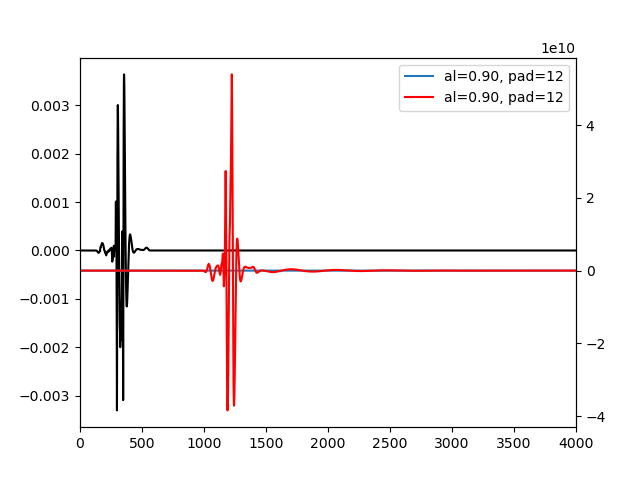

In [171]:
### HANDMADE TEST 
iz = 35
from scipy.signal import lfilter
i_east, i_north = 0, 10 

### We try to do the ropgation + attenuation step ourselves to avoid the step pb in FFT 
### 1. Pad signal in time domain with zeros 
orig_sig = AIRGLOW.VEL[i_east, i_north, :]
Nw = orig_sig.size
print(AIRGLOW.dt)

### Better pad: tukey taper
from scipy.signal.windows import tukey
fig, ax = plt.subplots()
ax.plot(orig_sig, "k")
#ax.plot(long_sig, "r")    
axb = ax.twinx()
# for dpad in [4,8,12]:
# for al in [0.8, 0.9, 0.95]:
dpad = 12
al = 0.9
long_sig = np.pad(orig_sig, ((0, int(dpad*Nw) )), mode='constant')
long_sig[Nw:] = tukey(int(2*dpad*Nw), alpha=al)[int(dpad*Nw):]*orig_sig[-1]
#ax.plot(tukey(int(8*Nw), alpha=0.5), "b")
### 2 Apply fft 
# print(orig_sig.shape)
long_sig_fft = np.fft.fft(long_sig)
Nfft = long_sig.size
## Nfft is 1875 in this example
### 3 calculate attenuation 
pad_freq = np.fft.fftfreq(Nfft, AIRGLOW.dt)
FFver, ZZver2 = np.meshgrid(abs(pad_freq), AIRGLOW.z_att_1_27_m)
attenuation = AIRGLOW.f_alpha_2d((ZZver2, FFver))
att_exp = np.exp(-AIRGLOW.dz_1_27_m*np.cumsum(attenuation, axis=0))   ### Supposes Np/m 
att_exp = att_exp[-AIRGLOW.Nz:,:]
### 4 Calculate phase shift 
phase_shift_z = np.zeros((AIRGLOW.Nz, long_sig.size), dtype = np.complex128)
travel_time = AIRGLOW.dz_1_27_m * np.cumsum(1/AIRGLOW.f_c(AIRGLOW.z_att_1_27_m))
travel_time = travel_time[-AIRGLOW.Nz:]
for jz in range(AIRGLOW.Nz):
    tau = float(travel_time[jz])  # ensure float64
    phase_shift_z[jz, :] = np.exp(-2j * np.pi * pad_freq * tau)

# Enforce Hermitian symmetry explicitly (works for odd/even N)
if Nfft % 2 == 0:
    pos = np.arange(1, Nfft//2)        # 1..(N/2-1)
    phase_shift_z[:, 0] = phase_shift_z[:, 0].real
    phase_shift_z[:, Nfft//2] = phase_shift_z[:, Nfft//2].real
else:
    print("here")
    pos = np.arange(1, (Nfft-1)//2 + 1)  # 1..(N-1)//2
    phase_shift_z[:, 0] = phase_shift_z[:, 0].real
def hermitian_error(H):
    N = H.size
    ks = np.arange(1, N)          # all except DC
    if N % 2 == 0:
        ks = ks[ks != N//2]       # skip Nyquist for even N
    partner = (-ks) % N
    return np.max(np.abs(H[ks] - np.conj(H[partner])))
def self_conj_error(H):
    errs = []
    errs.append(abs(H[0].imag))
    if H.size % 2 == 0:
        errs.append(abs(H[H.size//2].imag))
    return max(errs)
neg = (-pos) % Nfft
phase_shift_z[:, neg] = np.conj(phase_shift_z[:, pos])
print("hermitian_error:", hermitian_error(phase_shift_z[0]))
print("self_conj_error:", self_conj_error(phase_shift_z[0]))
### 5 filter long signal 
long_sig_filt_fft = long_sig_fft[None,:]*phase_shift_z*att_exp*AIRGLOW.amplification[:,None]
### Back to time domain 
long_sig_filt = np.fft.ifft(long_sig_filt_fft, axis=1)
### Filter low frequency + DC: 
#long_sig_filt = ar.butter_filter(long_sig_filt, 1/AIRGLOW.dt, 5e-3, None, axis=1, order=10)
#long_sig_filt-= long_sig_filt[:,0][:,None]
#long_sig_filt_fft = np.fft.fft(long_sig_filt)

### Apply VER filter 
fver_alt = AIRGLOW.f_VER_1_27(AIRGLOW.z_1_27_calc_m)[:,np.newaxis]
fdver_alt = AIRGLOW.f_dVER_1_27(AIRGLOW.z_1_27_calc_m)[:,np.newaxis]
### Compute VER and its vertical gradient (numpy gradient) TIME DOMAIN 
ver_vz = fver_alt * long_sig_filt_fft  # shape: (Nz, Nt)
dver_vz_z = fver_alt * np.gradient(long_sig_filt, AIRGLOW.z_1_27_calc_m, axis=0) + fdver_alt*long_sig_filt
dver_z = lfilter(AIRGLOW.b, AIRGLOW.a, dver_vz_z, axis=1)

dver_z = ar.butter_filter(dver_z, 1/AIRGLOW.dt, 5e-3, None, axis=1, order=10)

### Apply VER filter (fourier) 
#tf_phase_nightglow = -(AIRGLOW.tau/(1+1j*2*np.pi*pad_freq[None,:]*AIRGLOW.tau))
#dver_vz_z = fver_alt * np.gradient(long_sig_filt_fft, AIRGLOW.z_1_27_calc_m, axis=0) + fdver_alt*long_sig_filt_fft 
#mult = tf_phase_nightglow * dver_vz_z
#dver_z = np.fft.ifft(mult, axis=1).real


axb.plot(long_sig_filt[iz,:], label="al={:.2f}, pad={:d}".format(al, dpad))
axb.plot(dver_z[iz,:], c="r", label="al={:.2f}, pad={:d}".format(al, dpad))
ax.set_xlim(0,250*8/AIRGLOW.dt)
axb.legend()

